<a href="https://colab.research.google.com/github/susmitsingh01/cuda-triton-llm-kernels/blob/main/02_transpose.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Matrix Transpose

## Step 0: Prediction
- Operation: out[c][r] = in[r][c], N × N matrix, fp32
- Bytes moved: read 4 + write 4 = **8 bytes per element**, 8N² in total
- Work: **0 FLOPs**, pure data movement
- **Prediction: memory-bound.** The best possible transpose moves the same bytes as a plain copy,
  so the **copy kernel is the ceiling**.
- v0 (naive): reads coalesced, **writes uncoalesced** (consecutive threads write addresses N floats apart).
  Expect stores at ~32 sectors per request instead of 4, and v0 well below copy speed.

In [1]:
import platform
import subprocess
import pandas as pd

import torch
import triton


def env_info():
    smi = subprocess.run(
        ["nvidia-smi",
         "--query-gpu=name,driver_version,clocks.sm,clocks.mem,ecc.mode.current",
         "--format=csv,noheader"],
        capture_output=True, text=True,
    ).stdout.strip()
    return {
        "gpu": smi,
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "triton": triton.__version__,
        "python": platform.python_version(),
    }

In [2]:
env_info()

{'gpu': 'Tesla T4, 580.82.07, 300 MHz, 405 MHz, Enabled',
 'torch': '2.11.0+cu130',
 'cuda': '13.0',
 'triton': '3.6.0',
 'python': '3.13.15'}

In [4]:
def time_ms(fn, warmup=25, iters=100):
    flush = torch.empty(256 * 1024 * 1024, dtype=torch.uint8, device="cuda")   # 256 MB
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    stop = torch.cuda.Event(enable_timing=True)
    times = []
    for _ in range(iters):
        flush.zero_()                         # push inputs out of L2
        start.record()                        # marker before the kernel
        fn()
        stop.record()                         # marker after the kernel
        stop.synchronize()                    # wait until the GPU reaches 'stop'
        times.append(start.elapsed_time(stop))
    times.sort()
    return times[iters // 2]                  # median, in ms


def bench(impls, sizes, bytes_per_elem=12, dtype=torch.float32):
    rows = []
    for n in sizes:
        a = torch.randn(n, device="cuda", dtype=dtype)
        b = torch.randn(n, device="cuda", dtype=dtype)
        c = torch.empty_like(a)                         # preallocated output, like C++
        for name, fn in impls.items():
            fn(a, b, c)                                 # warm call (compile etc.)
            ms = time_ms(lambda: fn(a, b, c))
            gbps = bytes_per_elem * n / (ms * 1e-3) / 1e9
            rows.append({"impl": name, "n": n, "time_us": ms * 1e3, "GB/s": gbps})
    print(env_info())
    return pd.DataFrame(rows)

def format_n_as_power_of_2(n):
    if n == 0: return '2**0'
    k = 0
    temp_n = n
    while temp_n % 2 == 0 and temp_n > 1:
        temp_n //= 2
        k += 1
    if temp_n == 1:
        return f'2**{k}'
    else:
        # Fallback for numbers not exact powers of 2, though in this case they should be.
        return str(n)

In [48]:
%%writefile transpose.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <algorithm>

#define CHECK(call)                                                      \
    {                                                                    \
        cudaError_t err = (call);                                        \
        if (err != cudaSuccess) {                                        \
            printf("%s in %s at line %d\n", cudaGetErrorString(err),     \
                   __FILE__, __LINE__);                                  \
            exit(EXIT_FAILURE);                                          \
        }                                                                \
    }

#define TILE 32
#define COPY -1   // version number used for the copy kernel

#define BLOCK_ROWS 8     // v3 and copy_32x8: blocks of 32 x 8 threads
#define COPY_32X8 -2     // version number for the copy kernel with 32 x 8 blocks

// Reference ceiling: a plain copy with the same thread layout (8 bytes per element)
__global__ void copyKernel(float* in, float* out, int N) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    if (row < N && col < N) {
        out[row * N + col] = in[row * N + col];
    }
}

// v0: naive transpose
// Reads:  consecutive threads (threadIdx.x) -> consecutive columns of one row -> coalesced
// Writes: consecutive threads -> consecutive rows of one column, N floats apart -> NOT coalesced
__global__ void transposeKernel_v0(float* in, float* out, int N) {
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    if (row < N && col < N) {
        out[col * N + row] = in[row * N + col];
    }
}

// v1: transpose through a 32x32 shared-memory tile
__global__ void transposeKernel_v1(float* in, float* out, int N) {
    __shared__ float tile[TILE][TILE];

    // 1) Read a 32x32 tile of 'in' into shared memory.
    //    Coalesced: consecutive threads (threadIdx.x) read consecutive columns of a row.
    int col = blockIdx.x * TILE + threadIdx.x;
    int row = blockIdx.y * TILE + threadIdx.y;
    if (row < N && col < N) {
        tile[threadIdx.y][threadIdx.x] = in[row * N + col];
    }

    __syncthreads();   // every element of the tile must be loaded before anyone reads it

    // 2) Write the tile out transposed.
    //    The block that read tile (bx, by) of 'in' writes tile (by, bx) of 'out' (block indices swapped).
    //    Coalesced: consecutive threads (threadIdx.x) write consecutive columns of a row of 'out'.
    int outCol = blockIdx.y * TILE + threadIdx.x;
    int outRow = blockIdx.x * TILE + threadIdx.y;
    if (outRow < N && outCol < N) {
        out[outRow * N + outCol] = tile[threadIdx.x][threadIdx.y];   // reads a COLUMN of the tile
    }
}


// v2: v1 with a padded tile, to remove shared-memory bank conflicts
__global__ void transposeKernel_v2(float* in, float* out, int N) {
    __shared__ float tile[TILE][TILE + 1];   // 33 columns: the extra column shifts each row by one bank

    int col = blockIdx.x * TILE + threadIdx.x;
    int row = blockIdx.y * TILE + threadIdx.y;
    if (row < N && col < N) {
        tile[threadIdx.y][threadIdx.x] = in[row * N + col];
    }

    __syncthreads();

    int outCol = blockIdx.y * TILE + threadIdx.x;
    int outRow = blockIdx.x * TILE + threadIdx.y;
    if (outRow < N && outCol < N) {
        out[outRow * N + outCol] = tile[threadIdx.x][threadIdx.y];
    }
}


// Copy with 32 x 8 blocks: each thread copies 4 elements, 8 rows apart
__global__ void copyKernel_32x8(float* in, float* out, int N) {
    int col = blockIdx.x * TILE + threadIdx.x;
    int rowBase = blockIdx.y * TILE + threadIdx.y;
    for (int j = 0; j < TILE; j += BLOCK_ROWS) {
        int row = rowBase + j;
        if (row < N && col < N) {
            out[row * N + col] = in[row * N + col];
        }
    }
}

// v3: v2 with 32 x 8 blocks; each thread handles 4 rows of the 32 x 32 tile
__global__ void transposeKernel_v3(float* in, float* out, int N) {
    __shared__ float tile[TILE][TILE + 1];   // padded, as in v2

    // 1) Load the tile: each thread loads rows threadIdx.y, +8, +16, +24
    int col = blockIdx.x * TILE + threadIdx.x;
    int rowBase = blockIdx.y * TILE + threadIdx.y;
    for (int j = 0; j < TILE; j += BLOCK_ROWS) {
        int row = rowBase + j;
        if (row < N && col < N) {
            tile[threadIdx.y + j][threadIdx.x] = in[row * N + col];
        }
    }

    __syncthreads();

    // 2) Write the tile transposed, the same 4 rows per thread
    int outCol = blockIdx.y * TILE + threadIdx.x;
    int outRowBase = blockIdx.x * TILE + threadIdx.y;
    for (int j = 0; j < TILE; j += BLOCK_ROWS) {
        int outRow = outRowBase + j;
        if (outRow < N && outCol < N) {
            out[outRow * N + outCol] = tile[threadIdx.x][threadIdx.y + j];
        }
    }
}


// Launcher: picks the kernel by version number
void launchKernel(int version, float* in_d, float* out_d, int N) {
    dim3 grid(ceil(N / (float)TILE), ceil(N / (float)TILE));   // one block per 32 x 32 tile
    dim3 block(TILE, TILE);                                    // 32 x 32 = 1024 threads
    dim3 blockSmall(TILE, BLOCK_ROWS);                         // 32 x 8  = 256 threads

    if (version == COPY) {
        copyKernel<<<grid, block>>>(in_d, out_d, N);
    } else if (version == COPY_32X8) {
        copyKernel_32x8<<<grid, blockSmall>>>(in_d, out_d, N);
    } else if (version == 0) {
        transposeKernel_v0<<<grid, block>>>(in_d, out_d, N);
    } else if (version == 1) {
        transposeKernel_v1<<<grid, block>>>(in_d, out_d, N);
    } else if (version == 2) {
        transposeKernel_v2<<<grid, block>>>(in_d, out_d, N);
    } else if (version == 3) {
        transposeKernel_v3<<<grid, blockSmall>>>(in_d, out_d, N);
    }
}

const char* versionName(int version) {
    if (version == COPY) return "cuda_copy";
    if (version == COPY_32X8) return "cuda_copy_32x8";
    if (version == 0) return "cuda_v0";
    if (version == 1) return "cuda_v1";
    if (version == 2) return "cuda_v2";
    if (version == 3) return "cuda_v3";
    return "unknown";
}

Overwriting transpose.cu


In [49]:
%%writefile -a transpose.cu

// Host function: allocate, copy input to the GPU, launch, copy result back, free
void transpose(int version, float* in_h, float* out_h, int N) {
    int size = N * N * sizeof(float);
    float *in_d, *out_d;

    CHECK(cudaMalloc((void**)&in_d, size));
    CHECK(cudaMalloc((void**)&out_d, size));
    CHECK(cudaMemcpy(in_d, in_h, size, cudaMemcpyHostToDevice));

    launchKernel(version, in_d, out_d, N);
    CHECK(cudaGetLastError());

    CHECK(cudaMemcpy(out_h, out_d, size, cudaMemcpyDeviceToHost));
    CHECK(cudaFree(in_d));
    CHECK(cudaFree(out_d));
}

Appending to transpose.cu


In [50]:
%%writefile -a transpose.cu

// CPU reference
void transposeCPU(float* in, float* out, int N) {
    for (int row = 0; row < N; row++) {
        for (int col = 0; col < N; col++) {
            out[col * N + row] = in[row * N + col];
        }
    }
}

int checkCorrectness(int version, int N) {
    int count = N * N;
    float* in_h  = (float*)malloc(count * sizeof(float));
    float* out_h = (float*)malloc(count * sizeof(float));   // GPU result
    float* ref   = (float*)malloc(count * sizeof(float));   // expected result

    for (int i = 0; i < count; i++) {
        in_h[i] = rand() / (float)RAND_MAX;
    }

    transpose(version, in_h, out_h, N);

    if (version == COPY || version == COPY_32X8) {
        for (int i = 0; i < count; i++) ref[i] = in_h[i];   // copy: output = input
    } else {
        transposeCPU(in_h, ref, N);                          // transpose: output = input transposed
    }

    // Pure data movement: no arithmetic, so the result must match exactly
    int errors = 0;
    for (int i = 0; i < count; i++) {
        if (out_h[i] != ref[i]) errors++;
    }
    printf("# %s check N=%d: %s (%d mismatches)\n",
           versionName(version), N, errors == 0 ? "PASS" : "FAIL", errors);

    free(in_h);
    free(out_h);
    free(ref);
    return errors == 0;
}

Appending to transpose.cu


In [51]:
%%writefile -a transpose.cu

#define WARMUP 25
#define ITERS 100

float timeKernel(int version, int N) {
    int size = N * N * sizeof(float);
    float *in_d, *out_d;
    CHECK(cudaMalloc((void**)&in_d, size));
    CHECK(cudaMalloc((void**)&out_d, size));
    CHECK(cudaMemset(in_d, 0, size));

    int flushSize = 256 * 1024 * 1024;   // 256 MB, much larger than the 4 MB L2
    char* flush_d;
    CHECK(cudaMalloc((void**)&flush_d, flushSize));

    for (int i = 0; i < WARMUP; i++) {
        launchKernel(version, in_d, out_d, N);
    }
    CHECK(cudaDeviceSynchronize());

    cudaEvent_t start, stop;
    CHECK(cudaEventCreate(&start));
    CHECK(cudaEventCreate(&stop));

    float times[ITERS];
    for (int i = 0; i < ITERS; i++) {
        CHECK(cudaMemset(flush_d, 0, flushSize));
        CHECK(cudaEventRecord(start));
        launchKernel(version, in_d, out_d, N);
        CHECK(cudaEventRecord(stop));
        CHECK(cudaEventSynchronize(stop));
        CHECK(cudaEventElapsedTime(&times[i], start, stop));
    }
    CHECK(cudaGetLastError());
    std::sort(times, times + ITERS);

    CHECK(cudaEventDestroy(start));
    CHECK(cudaEventDestroy(stop));
    CHECK(cudaFree(in_d));
    CHECK(cudaFree(out_d));
    CHECK(cudaFree(flush_d));
    return times[ITERS / 2];   // median, in ms
}

Appending to transpose.cu


In [52]:
%%writefile -a transpose.cu

void profileOnce(int version, int N) {
    int size = N * N * sizeof(float);
    float *in_d, *out_d;
    CHECK(cudaMalloc((void**)&in_d, size));
    CHECK(cudaMalloc((void**)&out_d, size));
    CHECK(cudaMemset(in_d, 0, size));

    launchKernel(version, in_d, out_d, N);
    CHECK(cudaGetLastError());
    CHECK(cudaDeviceSynchronize());

    CHECK(cudaFree(in_d));
    CHECK(cudaFree(out_d));
}

int main(int argc, char** argv) {
    // ./transpose <version> <N>  ->  profile mode (use -1 for the copy kernel)
    if (argc == 3) {
        profileOnce(atoi(argv[1]), atoi(argv[2]));
        return 0;
    }

    int versions[] = {COPY, COPY_32X8, 0, 1, 2, 3};

    int numVersions = sizeof(versions) / sizeof(versions[0]);

    int checkSizes[] = {1, 33, 1000, 2048};   // 33 and 1000 are not multiples of 32
    int numCheckSizes = sizeof(checkSizes) / sizeof(checkSizes[0]);

    int benchSizes[] = {256, 512, 1024, 2048, 4096, 8192, 16384};
    int numSizes = sizeof(benchSizes) / sizeof(benchSizes[0]);

    int allPassed = 1;
    for (int v = 0; v < numVersions; v++) {
        for (int k = 0; k < numCheckSizes; k++) {
            if (!checkCorrectness(versions[v], checkSizes[k])) allPassed = 0;
        }
    }
    if (!allPassed) {
        printf("# correctness failed, not benchmarking\n");
        return 1;
    }

    printf("impl,N,time_us,GB/s\n");
    for (int v = 0; v < numVersions; v++) {
        for (int k = 0; k < numSizes; k++) {
            int N = benchSizes[k];
            float ms = timeKernel(versions[v], N);
            double gbps = 8.0 * N * N / (ms * 1e-3) / 1e9;   // 8 bytes per element
            printf("%s,%d,%.3f,%.2f\n", versionName(versions[v]), N, ms * 1000.0f, gbps);
        }
    }
    return 0;
}

Appending to transpose.cu


In [53]:
!nvcc -O3 -arch=native -lineinfo -o transpose transpose.cu && ./transpose | tee cuda_transpose.csv

# cuda_copy check N=1: PASS (0 mismatches)
# cuda_copy check N=33: PASS (0 mismatches)
# cuda_copy check N=1000: PASS (0 mismatches)
# cuda_copy check N=2048: PASS (0 mismatches)
# cuda_copy_32x8 check N=1: PASS (0 mismatches)
# cuda_copy_32x8 check N=33: PASS (0 mismatches)
# cuda_copy_32x8 check N=1000: PASS (0 mismatches)
# cuda_copy_32x8 check N=2048: PASS (0 mismatches)
# cuda_v0 check N=1: PASS (0 mismatches)
# cuda_v0 check N=33: PASS (0 mismatches)
# cuda_v0 check N=1000: PASS (0 mismatches)
# cuda_v0 check N=2048: PASS (0 mismatches)
# cuda_v1 check N=1: PASS (0 mismatches)
# cuda_v1 check N=33: PASS (0 mismatches)
# cuda_v1 check N=1000: PASS (0 mismatches)
# cuda_v1 check N=2048: PASS (0 mismatches)
# cuda_v2 check N=1: PASS (0 mismatches)
# cuda_v2 check N=33: PASS (0 mismatches)
# cuda_v2 check N=1000: PASS (0 mismatches)
# cuda_v2 check N=2048: PASS (0 mismatches)
# cuda_v3 check N=1: PASS (0 mismatches)
# cuda_v3 check N=33: PASS (0 mismatches)
# cuda_v3 check N=1000: PA

In [25]:
import torch._dynamo
torch._dynamo.reset()
torch._dynamo.config.recompile_limit = 64

def torch_transpose(a, c):
    c.copy_(a.t())   # a.t() is a view; copy_ does the actual data movement into c

compile_static = torch.compile(torch_transpose, dynamic=False)

def bench2d(impls, Ns):
    rows = []
    for N in Ns:
        a = torch.randn(N, N, device="cuda")
        c = torch.empty_like(a)
        for name, fn in impls.items():
            fn(a, c)                                   # warm call (compile etc.)
            torch.testing.assert_close(c, a.t())       # quick correctness check
            ms = time_ms(lambda: fn(a, c))
            gbps = 8 * N * N / (ms * 1e-3) / 1e9
            rows.append({"impl": name, "N": N, "time_us": ms * 1e3, "GB/s": gbps})
    print(env_info())
    return pd.DataFrame(rows)

Ns = [2**k for k in range(8, 15)]   # 256 ... 16384
df_py = bench2d({"torch_eager": torch_transpose, "compile_static": compile_static}, Ns)

{'gpu': 'Tesla T4, 580.82.07, 1305 MHz, 5000 MHz, Enabled', 'torch': '2.11.0+cu130', 'cuda': '13.0', 'triton': '3.6.0', 'python': '3.13.15'}


impl,compile_static,cuda_copy,cuda_copy_32x8,cuda_v0,cuda_v1,cuda_v2,cuda_v3,torch_eager,triton,v0 / copy,v1 / copy,v2 / copy,v2 / v1,v3 / copy,v3 / copy_32x8,v3 / v2
N,,,,,,,,,,,,,,,,
2**8,81.512,60.46,70.93,47.35,55.35,78.77,84.45,60.458,80.314,0.783,0.915,1.303,1.423,1.397,1.191,1.072
2**9,164.663,128.00,140.33,75.59,100.98,144.04,160.63,113.581,169.782,0.591,0.789,1.125,1.426,1.255,1.145,1.115
2**10,205.603,204.32,196.22,93.52,127.50,195.19,204.80,139.587,211.577,0.458,0.624,0.955,1.531,1.002,1.044,1.049
2**11,215.579,231.88,227.51,95.39,138.32,207.39,202.12,139.847,221.780,0.411,0.597,0.894,1.499,0.872,0.888,0.975
2**12,202.330,239.99,234.06,92.96,140.64,204.65,197.36,135.274,222.912,0.387,0.586,0.853,1.455,0.822,0.843,0.964
2**13,199.615,241.08,237.51,84.32,139.93,201.81,194.39,102.480,223.831,0.350,0.580,0.837,1.442,0.806,0.818,0.963
2**14,198.113,236.98,234.39,82.27,139.61,199.42,191.09,86.874,224.136,0.347,0.589,0.842,1.428,0.806,0.815,0.958


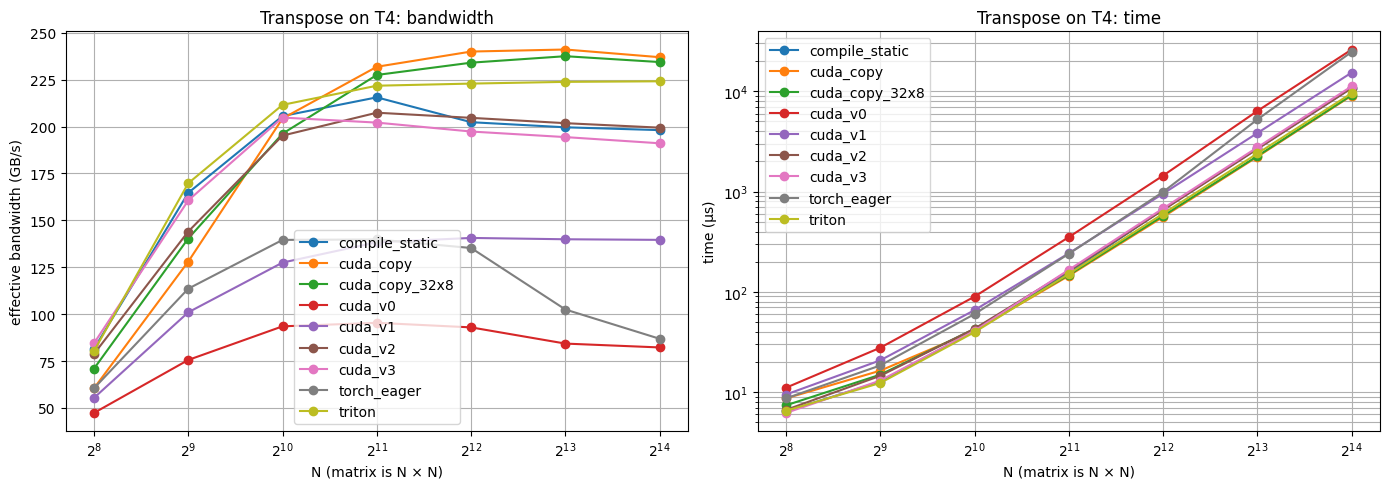

In [54]:
import matplotlib.pyplot as plt

df_cuda = pd.read_csv("cuda_transpose.csv", comment="#")
df_all = pd.concat([df_py, df_cuda], ignore_index=True)

# Table: bandwidth of every implementation, plus ratios
pivot = df_all.pivot(index="N", columns="impl", values="GB/s")
pivot["v0 / copy"] = pivot["cuda_v0"] / pivot["cuda_copy"]
pivot["v1 / copy"] = pivot["cuda_v1"] / pivot["cuda_copy"]
pivot["v2 / copy"] = pivot["cuda_v2"] / pivot["cuda_copy"]
pivot["v2 / v1"]   = pivot["cuda_v2"] / pivot["cuda_v1"]
pivot["v3 / copy"]       = pivot["cuda_v3"] / pivot["cuda_copy"]
pivot["v3 / copy_32x8"]  = pivot["cuda_v3"] / pivot["cuda_copy_32x8"]
pivot["v3 / v2"]         = pivot["cuda_v3"] / pivot["cuda_v2"]
display(pivot.round(3).rename(index=format_n_as_power_of_2))

# Plots: bandwidth (left) and time (right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for impl, g in df_all.groupby("impl"):
    g = g.sort_values("N")
    ax1.plot(g["N"], g["GB/s"], marker="o", label=impl)
    ax2.plot(g["N"], g["time_us"], marker="o", label=impl)

ax1.set_xscale("log", base=2)
ax1.set_xlabel("N (matrix is N × N)")
ax1.set_ylabel("effective bandwidth (GB/s)")
ax1.set_title("Transpose on T4: bandwidth")
ax1.grid(True)
ax1.legend()

ax2.set_xscale("log", base=2)
ax2.set_yscale("log")
ax2.set_xlabel("N (matrix is N × N)")
ax2.set_ylabel("time (µs)")
ax2.set_title("Transpose on T4: time")
ax2.grid(True, which="both")
ax2.legend()

plt.tight_layout()
plt.savefig("transpose_t4_v2.png", dpi=150)
plt.show()

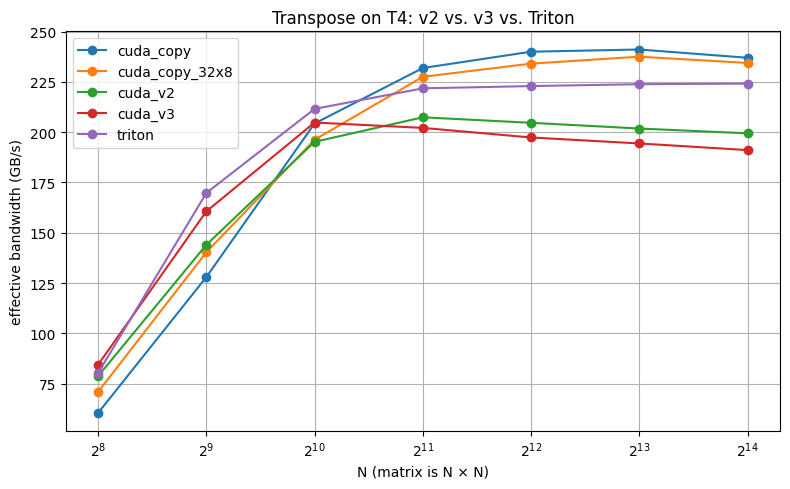

In [55]:
focus = ["cuda_copy", "cuda_copy_32x8", "cuda_v2", "cuda_v3", "triton"]

fig, ax = plt.subplots(figsize=(8, 5))
for impl in focus:
    g = df_all[df_all["impl"] == impl].sort_values("N")
    ax.plot(g["N"], g["GB/s"], marker="o", label=impl)
ax.set_xscale("log", base=2)
ax.set_xlabel("N (matrix is N × N)")
ax.set_ylabel("effective bandwidth (GB/s)")
ax.set_title("Transpose on T4: v2 vs. v3 vs. Triton")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.savefig("transpose_t4_v3_focus.png", dpi=150)
plt.show()

In [13]:
!ncu --section SpeedOfLight --section MemoryWorkloadAnalysis --metrics l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum,l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum,l1tex__t_sectors_pipe_lsu_mem_global_op_st.sum,l1tex__t_requests_pipe_lsu_mem_global_op_st.sum,dram__bytes_read.sum,dram__bytes_write.sum ./transpose -1 4096

==PROF== Connected to process 8790 (/content/transpose)
==PROF== Profiling "copyKernel" - 0: 0%....50%....100% - 12 passes
==PROF== Disconnected from process 8790
[8790] transpose@127.0.0.1
  copyKernel(float *, float *, int) (128, 128, 1)x(32, 32, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: Command line profiler metrics
    ----------------------------------------------- ----------- ------------
    Metric Name                                     Metric Unit Metric Value
    ----------------------------------------------- ----------- ------------
    dram__bytes_read.sum                                  Mbyte        78.24
    dram__bytes_write.sum                                 Mbyte        75.32
    l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum                  524,288
    l1tex__t_requests_pipe_lsu_mem_global_op_st.sum                  524,288
    l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum       sector    2,097,152
    l1tex__t_sectors_pipe_lsu_mem_global_op_st.sum

In [14]:
!ncu --section SpeedOfLight --section MemoryWorkloadAnalysis --metrics l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum,l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum,l1tex__t_sectors_pipe_lsu_mem_global_op_st.sum,l1tex__t_requests_pipe_lsu_mem_global_op_st.sum,dram__bytes_read.sum,dram__bytes_write.sum ./transpose 0 4096

==PROF== Connected to process 8861 (/content/transpose)
==PROF== Profiling "transposeKernel_v0" - 0: 0%....50%....100% - 12 passes
==PROF== Disconnected from process 8861
[8861] transpose@127.0.0.1
  transposeKernel_v0(float *, float *, int) (128, 128, 1)x(32, 32, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: Command line profiler metrics
    ----------------------------------------------- ----------- ------------
    Metric Name                                     Metric Unit Metric Value
    ----------------------------------------------- ----------- ------------
    dram__bytes_read.sum                                  Mbyte       277.49
    dram__bytes_write.sum                                 Mbyte        83.10
    l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum                  524,288
    l1tex__t_requests_pipe_lsu_mem_global_op_st.sum                  524,288
    l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum       sector    2,097,152
    l1tex__t_sectors_pipe_lsu_mem_

In [15]:
!ncu --clock-control none --section SpeedOfLight --section Occupancy ./transpose -1 4096

==WARNING== Note: Running with unmodified GPU clocks. If not controlled otherwise, profiling results may be inconsistent.
==PROF== Connected to process 10180 (/content/transpose)
==PROF== Profiling "copyKernel" - 0: 0%....50%....100% - 8 passes
==PROF== Disconnected from process 10180
[10180] transpose@127.0.0.1
  copyKernel(float *, float *, int) (128, 128, 1)x(32, 32, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    DRAM Frequency                  Ghz         5.00
    SM Frequency                    Ghz         1.03
    Elapsed Cycles                cycle      585,426
    Memory Throughput                 %        81.80
    DRAM Throughput                   %        81.80
    Duration                         us       565.66
    L1/TEX Cache Throughput           %        14.98
    L2 Cache

In [21]:
!ncu --section SpeedOfLight --section MemoryWorkloadAnalysis --metrics l1tex__t_sectors_pipe_lsu_mem_global_op_st.sum,l1tex__t_requests_pipe_lsu_mem_global_op_st.sum,dram__bytes_read.sum,dram__bytes_write.sum,l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld.sum,l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_st.sum ./transpose 1 4096

==PROF== Connected to process 11092 (/content/transpose)
==PROF== Disconnected from process 11092
==WARNING== No kernels were profiled.


In [34]:
!ncu --section SpeedOfLight --section Occupancy --section WarpStateStats --metrics l1tex__t_sectors_pipe_lsu_mem_global_op_st.sum,l1tex__t_requests_pipe_lsu_mem_global_op_st.sum,dram__bytes_read.sum,dram__bytes_write.sum,l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld.sum,l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_st.sum ./transpose 1 4096

==PROF== Connected to process 14602 (/content/transpose)
==PROF== Profiling "transposeKernel_v1" - 0: 0%....50%....100% - 12 passes
==PROF== Disconnected from process 14602
[14602] transpose@127.0.0.1
  transposeKernel_v1(float *, float *, int) (128, 128, 1)x(32, 32, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: Command line profiler metrics
    -------------------------------------------------------- ----------- ------------
    Metric Name                                              Metric Unit Metric Value
    -------------------------------------------------------- ----------- ------------
    dram__bytes_read.sum                                           Mbyte        86.01
    dram__bytes_write.sum                                          Mbyte        82.91
    l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld.sum               16,252,928
    l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_st.sum                        0
    l1tex__t_requests_pipe_lsu_mem_global_op_

In [35]:
!ncu --section SpeedOfLight --section Occupancy --section WarpStateStats --metrics l1tex__t_sectors_pipe_lsu_mem_global_op_st.sum,l1tex__t_requests_pipe_lsu_mem_global_op_st.sum,dram__bytes_read.sum,dram__bytes_write.sum,l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld.sum,l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_st.sum ./transpose 2 4096

==PROF== Connected to process 14676 (/content/transpose)
==PROF== Profiling "transposeKernel_v2" - 0: 0%....50%....100% - 12 passes
==PROF== Disconnected from process 14676
[14676] transpose@127.0.0.1
  transposeKernel_v2(float *, float *, int) (128, 128, 1)x(32, 32, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: Command line profiler metrics
    -------------------------------------------------------- ----------- ------------
    Metric Name                                              Metric Unit Metric Value
    -------------------------------------------------------- ----------- ------------
    dram__bytes_read.sum                                           Mbyte        77.40
    dram__bytes_write.sum                                          Mbyte        82.80
    l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld.sum                        0
    l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_st.sum                        0
    l1tex__t_requests_pipe_lsu_mem_global_op_

In [36]:
%%writefile triton_transpose.py
import torch
import triton
import triton.language as tl


@triton.autotune(
    configs=[
        triton.Config({"BLOCK_M": bm, "BLOCK_N": bn}, num_warps=w)
        for bm in [32, 64]
        for bn in [32, 64]
        for w in [2, 4, 8]
    ],
    key=["N"],
)
@triton.jit
def transpose_kernel(in_ptr, out_ptr, N, BLOCK_M: tl.constexpr, BLOCK_N: tl.constexpr):
    pid_m = tl.program_id(0)   # which block of rows
    pid_n = tl.program_id(1)   # which block of columns

    rows = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)   # BLOCK_M row indices
    cols = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)   # BLOCK_N column indices

    # Load a BLOCK_M x BLOCK_N tile: element [r][c] of the tile is in[rows[r]][cols[c]]
    in_mask = (rows[:, None] < N) & (cols[None, :] < N)
    x = tl.load(in_ptr + rows[:, None] * N + cols[None, :], mask=in_mask)

    # Store the transposed tile: out[cols[c]][rows[r]] = in[rows[r]][cols[c]]
    out_mask = (cols[:, None] < N) & (rows[None, :] < N)
    tl.store(out_ptr + cols[:, None] * N + rows[None, :], tl.trans(x), mask=out_mask)


def triton_transpose(a, c):
    N = a.shape[0]
    grid = lambda meta: (triton.cdiv(N, meta["BLOCK_M"]), triton.cdiv(N, meta["BLOCK_N"]))
    transpose_kernel[grid](a, c, N)

Writing triton_transpose.py


In [37]:
import importlib, triton_transpose
importlib.reload(triton_transpose)                 # picks up edits if you rerun Cell 1
from triton_transpose import triton_transpose as triton_t, transpose_kernel

# correctness, including sizes that aren't multiples of the tile
for N in [1, 33, 1000, 2048]:
    a = torch.randn(N, N, device="cuda")
    c = torch.empty_like(a)
    triton_t(a, c)
    torch.testing.assert_close(c, a.t())
print("triton transpose: 4 sizes passed")

df_py = bench2d({
    "torch_eager": torch_transpose,
    "compile_static": compile_static,
    "triton": triton_t,
}, Ns)

triton transpose: 4 sizes passed
{'gpu': 'Tesla T4, 580.82.07, 1380 MHz, 5000 MHz, Enabled', 'torch': '2.11.0+cu130', 'cuda': '13.0', 'triton': '3.6.0', 'python': '3.13.15'}


impl,compile_static,cuda_copy,cuda_v0,cuda_v1,cuda_v2,torch_eager,triton,v0 / copy,v1 / copy,v2 / copy,v2 / v1,triton / copy
N,,,,,,,,,,,,
2**8,81.512,53.19,46.68,55.35,78.77,60.458,80.314,0.878,1.041,1.481,1.423,1.510
2**9,164.663,114.17,76.92,100.98,140.64,113.581,169.782,0.674,0.884,1.232,1.393,1.487
2**10,205.603,203.84,93.82,128.00,195.05,139.587,211.577,0.460,0.628,0.957,1.524,1.038
2**11,215.579,230.76,96.60,139.36,207.64,139.847,221.780,0.419,0.604,0.900,1.490,0.961
2**12,202.330,239.18,93.48,141.42,204.48,135.274,222.912,0.391,0.591,0.855,1.446,0.932
2**13,199.615,241.00,85.18,141.62,201.84,102.480,223.831,0.353,0.588,0.838,1.425,0.929
2**14,198.113,236.97,83.14,140.44,199.38,86.874,224.136,0.351,0.593,0.841,1.420,0.946


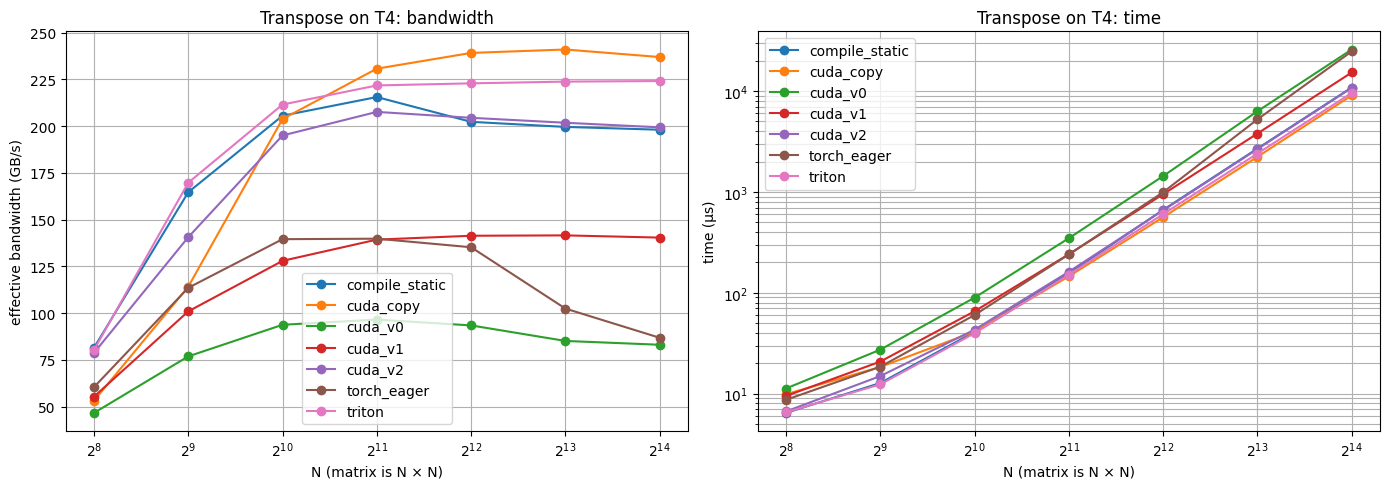

In [39]:
import matplotlib.pyplot as plt

df_cuda = pd.read_csv("cuda_transpose.csv", comment="#")
df_all = pd.concat([df_py, df_cuda], ignore_index=True)

# Table: bandwidth of every implementation, plus ratios
pivot = df_all.pivot(index="N", columns="impl", values="GB/s")
pivot["v0 / copy"] = pivot["cuda_v0"] / pivot["cuda_copy"]
pivot["v1 / copy"] = pivot["cuda_v1"] / pivot["cuda_copy"]
pivot["v2 / copy"] = pivot["cuda_v2"] / pivot["cuda_copy"]
pivot["v2 / v1"]   = pivot["cuda_v2"] / pivot["cuda_v1"]
pivot["triton / copy"] = pivot["triton"] / pivot["cuda_copy"]
display(pivot.round(3).rename(index=format_n_as_power_of_2))

# Plots: bandwidth (left) and time (right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for impl, g in df_all.groupby("impl"):
    g = g.sort_values("N")
    ax1.plot(g["N"], g["GB/s"], marker="o", label=impl)
    ax2.plot(g["N"], g["time_us"], marker="o", label=impl)

ax1.set_xscale("log", base=2)
ax1.set_xlabel("N (matrix is N × N)")
ax1.set_ylabel("effective bandwidth (GB/s)")
ax1.set_title("Transpose on T4: bandwidth")
ax1.grid(True)
ax1.legend()

ax2.set_xscale("log", base=2)
ax2.set_yscale("log")
ax2.set_xlabel("N (matrix is N × N)")
ax2.set_ylabel("time (µs)")
ax2.set_title("Transpose on T4: time")
ax2.grid(True, which="both")
ax2.legend()

plt.tight_layout()
plt.savefig("transpose_t4_v2.png", dpi=150)
plt.show()

In [40]:
for N in [2**10, 2**12, 2**14]:
    a = torch.randn(N, N, device="cuda"); c = torch.empty_like(a)
    triton_t(a, c)
    print(N, transpose_kernel.best_config)

1024 BLOCK_M: 64, BLOCK_N: 64, num_warps: 8, num_ctas: 1, num_stages: 3, maxnreg: None
4096 BLOCK_M: 64, BLOCK_N: 64, num_warps: 2, num_ctas: 1, num_stages: 3, maxnreg: None
16384 BLOCK_M: 64, BLOCK_N: 64, num_warps: 2, num_ctas: 1, num_stages: 3, maxnreg: None


In [41]:
BM, BN, W = 32, 32, 4   # ← set from best_config at N = 4096

N = 4096
a = torch.randn(N, N, device="cuda"); c = torch.empty_like(a)
grid = (triton.cdiv(N, BM), triton.cdiv(N, BN))
k = transpose_kernel.fn[grid](a, c, N, BLOCK_M=BM, BLOCK_N=BN, num_warps=W)

ttgir = k.asm["ttgir"]
print("\n".join(l for l in ttgir.splitlines() if l.startswith("#")))   # the layout definitions
print("convert_layout ops:", ttgir.count("convert_layout"))
open("triton_transpose_4096.cubin", "wb").write(k.asm["cubin"])

#blocked = #ttg.blocked<{sizePerThread = [1, 4], threadsPerWarp = [4, 8], warpsPerCTA = [4, 1], order = [1, 0]}>
#blocked1 = #ttg.blocked<{sizePerThread = [4, 1], threadsPerWarp = [8, 4], warpsPerCTA = [1, 4], order = [0, 1]}>
#loc = loc("/content/triton_transpose.py":16:0)
#loc29 = loc("in_ptr"(#loc))
#loc30 = loc("out_ptr"(#loc))
#loc31 = loc("N"(#loc))
#loc1 = loc(unknown)
#loc2 = loc("/content/triton_transpose.py":17:26)
#loc3 = loc("/content/triton_transpose.py":18:26)
#loc4 = loc("/content/triton_transpose.py":20:19)
#loc5 = loc("/content/triton_transpose.py":20:42)
#loc6 = loc("/content/triton_transpose.py":20:29)
#loc7 = loc("/content/triton_transpose.py":21:19)
#loc8 = loc("/content/triton_transpose.py":21:29)
#loc9 = loc("/content/triton_transpose.py":24:20)
#loc10 = loc("/content/triton_transpose.py":24:31)
#loc11 = loc("/content/triton_transpose.py":24:42)
#loc12 = loc("/content/triton_transpose.py":24:53)
#loc13 = loc("/content/triton_transpose.py":24:37)
#loc14 = loc("/co

9952

In [42]:
!cuobjdump -sass triton_transpose_4096.cubin | grep -E "LDG|STG|LDS|STS|BAR"

        /*01c0*/               @P1 LDG.E.128.SYS R4, [R12] ;                        /* 0x000000000c041381 */
        /*01d0*/               @P0 LDG.E.128.SYS R8, [R14] ;                        /* 0x000000000e080381 */
        /*03a0*/                   STS [R19], R4 ;                                  /* 0x0000000413007388 */
        /*03b0*/                   STS [R12+0x80], R5 ;                             /* 0x000080050c007388 */
        /*03c0*/                   STS [R13+0x100], R6 ;                            /* 0x000100060d007388 */
        /*03d0*/                   STS [R14+0x180], R7 ;                            /* 0x000180070e007388 */
        /*03e0*/                   STS [R15], R8 ;                                  /* 0x000000080f007388 */
        /*0410*/                   STS [R16+0x80], R9 ;                             /* 0x0000800910007388 */
        /*0430*/                   STS [R21+0x100], R10 ;                           /* 0x0001000a15007388 */
        /*0450*/   

In [43]:
%%writefile profile_triton_transpose.py
import torch, triton
from triton_transpose import transpose_kernel

BM, BN, W = 32, 32, 4   # ← same winning config as Cell 3
N = 4096
a = torch.randn(N, N, device="cuda"); c = torch.empty_like(a)
grid = (triton.cdiv(N, BM), triton.cdiv(N, BN))
transpose_kernel.fn[grid](a, c, N, BLOCK_M=BM, BLOCK_N=BN, num_warps=W)
torch.cuda.synchronize()

Writing profile_triton_transpose.py


In [44]:
!ncu -k regex:transpose_kernel -c 1 --section SpeedOfLight --metrics l1tex__t_sectors_pipe_lsu_mem_global_op_st.sum,l1tex__t_requests_pipe_lsu_mem_global_op_st.sum,l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld.sum,l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_st.sum ./python profile_triton_transpose.py

==PROF== Connected to process 17326 (/usr/bin/python3.13)
==PROF== Profiling "transpose_kernel": 0%....50%....100% - 10 passes
==PROF== Disconnected from process 17326
[17326] python3.13@127.0.0.1
  transpose_kernel (128, 128, 1)x(128, 1, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: Command line profiler metrics
    -------------------------------------------------------- ----------- ------------
    Metric Name                                              Metric Unit Metric Value
    -------------------------------------------------------- ----------- ------------
    l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld.sum                        0
    l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_st.sum                        0
    l1tex__t_requests_pipe_lsu_mem_global_op_st.sum                           131,072
    l1tex__t_sectors_pipe_lsu_mem_global_op_st.sum                sector    2,097,152
    -------------------------------------------------------- ----------- -

In [56]:
%%writefile profile_triton_transpose.py
import torch, triton
from triton_transpose import transpose_kernel

BM, BN, W = 64, 64, 2   # the actual winner at N = 4096
N = 4096
a = torch.randn(N, N, device="cuda"); c = torch.empty_like(a)
grid = (triton.cdiv(N, BM), triton.cdiv(N, BN))
transpose_kernel.fn[grid](a, c, N, BLOCK_M=BM, BLOCK_N=BN, num_warps=W)
torch.cuda.synchronize()

Overwriting profile_triton_transpose.py


In [57]:
!ncu -k regex:transpose_kernel -c 1 --section SpeedOfLight --metrics dram__bytes_read.sum,dram__bytes_write.sum,l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum,l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum python profile_triton_transpose.py

==PROF== Connected to process 29334 (/usr/bin/python3.13)
==PROF== Profiling "transpose_kernel": 0%....50%....100% - 10 passes
==PROF== Disconnected from process 29334
[29334] python3.13@127.0.0.1
  transpose_kernel (64, 64, 1)x(64, 1, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: Command line profiler metrics
    ----------------------------------------------- ----------- ------------
    Metric Name                                     Metric Unit Metric Value
    ----------------------------------------------- ----------- ------------
    dram__bytes_read.sum                                  Mbyte        84.57
    dram__bytes_write.sum                                 Mbyte        75.51
    l1tex__t_requests_pipe_lsu_mem_global_op_ld.sum                  131,072
    l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum       sector    2,097,152
    ----------------------------------------------- ----------- ------------

    Section: GPU Speed Of Light Throughput
    ---------------